In [16]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [17]:
# Cell 1: Imports and Device Setup

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Verify GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [18]:
# Cell 2: Data Loading Function

# Set folder paths
# Set folder paths
DATASET_DIR = "dataset_segmentation"
IMAGES_DIR = os.path.join(DATASET_DIR, "Images")
MASKS_DIR = os.path.join(DATASET_DIR, "Ground-truths")

def load_data(images_dir, masks_dir, img_size=(256, 256)):
    image_paths = sorted(glob(os.path.join(images_dir, "*")))
    mask_paths = sorted(glob(os.path.join(masks_dir, "*")))
    
    images = []
    masks = []
    
    for img_p, mask_p in zip(image_paths, mask_paths):
        img = cv2.imread(img_p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size) / 255.0
        
        mask = cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, img_size) / 255.0
        mask = np.where(mask > 0.5, 1.0, 0.0)
        
        images.append(img)
        masks.append(mask)
        
    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)

print("Loading dataset at 256x256 resolution...")
images, masks = load_data(IMAGES_DIR, MASKS_DIR, img_size=(256, 256))
print(f"Loaded {len(images)} images and {len(masks)} masks.")

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(images, masks, test_size=0.20, random_state=42)
print(f"Train set: {X_train.shape[0]} | Test set: {X_test.shape[0]}")

Loading dataset at 256x256 resolution...
Loaded 3064 images and 3064 masks.
Train set: 2451 | Test set: 613


In [19]:
# Cell 3: PyTorch Dataset & DataLoader

class BrainTumorDataset(Dataset):
    def __init__(self, images, masks):
        # Convert NumPy (N, H, W, C) -> PyTorch Tensor (N, C, H, W)
        self.images = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
        # Masks (N, H, W) -> PyTorch Tensor (N, 1, H, W)
        self.masks = torch.tensor(masks, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

## Increased batch size to 16 for 256x256 resolution
BATCH_SIZE = 16

train_dataset = BrainTumorDataset(X_train, y_train)
test_dataset = BrainTumorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

In [25]:
# Cell 4: Model Architecture (U-Net) & Loss Function

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(128, 64)
        
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        
        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up1(x)
        
        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up2(x)
        
        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up3(x)
        
        # Returns raw logits (no Sigmoid here)
        return self.outc(x)


class DiceBCEWithLogitsLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceBCEWithLogitsLoss, self).__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        # BCE with Logits is fully compatible with autocast
        bce_loss = self.bce(logits, targets)
        
        # Apply sigmoid to compute Dice loss safely
        probs = torch.sigmoid(logits)
        inputs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (inputs_flat.sum() + targets_flat.sum() + self.smooth)
        
        return bce_loss + dice_loss

# Re-instantiate model and criterion
model = UNet(in_channels=3, out_channels=1).to(device)
criterion = DiceBCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [26]:
# Cell 5. import callbacks

class ModelCheckpointAndEarlyStopping:
    """
    Callback to automatically save the best model weights and 
    trigger early stopping if validation loss plateaus.
    """
    def __init__(self, filepath="saved_models/best_unet_512.pth", patience=5, min_delta=0.0001, verbose=True):
        self.filepath = filepath
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        
        self.best_loss = float('inf')
        self.patience_counter = 0
        self.early_stop = False
        
        # Ensure target directory exists
        os.makedirs(os.path.dirname(self.filepath), exist_ok=True)

    def __call__(self, val_loss, model):
        # Check if validation loss improved significantly
        if val_loss < (self.best_loss - self.min_delta):
            if self.verbose:
                print(f"  --> Val loss improved ({self.best_loss:.4f} -> {val_loss:.4f}). Saving model state...")
            self.best_loss = val_loss
            self.patience_counter = 0
            
            # Save best weights
            torch.save(model.state_dict(), self.filepath)
        else:
            self.patience_counter += 1
            if self.verbose:
                print(f"  --> Val loss did not improve. EarlyStopping counter: {self.patience_counter}/{self.patience}")
            
            if self.patience_counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print("  [!] Early stopping triggered. Halting training.")

In [27]:
# Cell 6. Metrics Helper Functions

def compute_metrics(logits, targets, smooth=1e-6):
    """
    Computes Dice Score and IoU using logits input.
    """
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    
    inputs_flat = preds.view(-1)
    targets_flat = targets.view(-1)
    
    intersection = (inputs_flat * targets_flat).sum()
    total = inputs_flat.sum() + targets_flat.sum()
    union = total - intersection
    
    dice = (2. * intersection + smooth) / (total + smooth)
    iou = (intersection + smooth) / (union + smooth)
    
    return dice.item(), iou.item()

In [28]:
import sys
from tqdm import tqdm
from torch.amp import autocast, GradScaler

# Mixed Precision Scaler for CUDA
scaler = GradScaler('cuda')

EPOCHS = 20

# Initialize Callback
checkpoint_callback = ModelCheckpointAndEarlyStopping(
    filepath="saved_models/best_unet_256.pth", 
    patience=5, 
    verbose=True
)

for epoch in range(EPOCHS):
    # ---------------- TRAINING PHASE ----------------
    model.train()
    train_loss, train_dice, train_iou = 0.0, 0.0, 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}] Train", file=sys.stdout)
    for images, masks in train_bar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Explicitly pass 'cuda' as the device_type
        with autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, masks)
            
        # Scaled Backward Pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        b_loss = loss.item()
        b_dice, b_iou = compute_metrics(outputs, masks)
        
        train_loss += b_loss * images.size(0)
        train_dice += b_dice * images.size(0)
        train_iou += b_iou * images.size(0)
        
        train_bar.set_postfix(loss=f"{b_loss:.4f}", dice=f"{b_dice:.4f}")
        
    train_loss /= len(train_loader.dataset)
    train_dice /= len(train_loader.dataset)
    train_iou /= len(train_loader.dataset)
    
    # ---------------- VALIDATION PHASE ----------------
    model.eval()
    val_loss, val_dice, val_iou = 0.0, 0.0, 0.0
    
    val_bar = tqdm(test_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}] Val", file=sys.stdout)
    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            with autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)
            
            b_loss = loss.item()
            b_dice, b_iou = compute_metrics(outputs, masks)
            
            val_loss += b_loss * images.size(0)
            val_dice += b_dice * images.size(0)
            val_iou += b_iou * images.size(0)
            
            val_bar.set_postfix(loss=f"{b_loss:.4f}", dice=f"{b_dice:.4f}")
            
    val_loss /= len(test_loader.dataset)
    val_dice /= len(test_loader.dataset)
    val_iou /= len(test_loader.dataset)
    
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS:02d} | "
        f"Train Loss: {train_loss:.4f} - Train Dice: {train_dice:.4f} - Train IoU: {train_iou:.4f} | "
        f"Val Loss: {val_loss:.4f} - Val Dice: {val_dice:.4f} - Val IoU: {val_iou:.4f}"
    )
    
    checkpoint_callback(val_loss, model)
    if checkpoint_callback.early_stop:
        print("Training stopped early!")
        break

# Reload best model weights
model.load_state_dict(torch.load("saved_models/best_unet_256.pth"))
print("Loaded best model weights successfully!")

Epoch [1/20] Val: 100%|██████████| 39/39 [00:03<00:00,  9.83it/s, dice=0.0000, loss=1.2644]
Epoch 01/20 | Train Loss: 1.3326 - Train Dice: 0.0065 - Train IoU: 0.0033 | Val Loss: 1.2660 - Val Dice: 0.0001 - Val IoU: 0.0000
  --> Val loss improved (inf -> 1.2660). Saving model state...
Epoch [2/20] Val: 100%|██████████| 39/39 [00:03<00:00,  9.99it/s, dice=0.0000, loss=1.2072]
Epoch 02/20 | Train Loss: 1.2311 - Train Dice: 0.0001 - Train IoU: 0.0000 | Val Loss: 1.2039 - Val Dice: 0.0000 - Val IoU: 0.0000
  --> Val loss improved (1.2660 -> 1.2039). Saving model state...
Epoch [3/20] Val: 100%|██████████| 39/39 [00:03<00:00,  9.97it/s, dice=0.0161, loss=1.1562]
Epoch 03/20 | Train Loss: 1.1775 - Train Dice: 0.0477 - Train IoU: 0.0262 | Val Loss: 1.1579 - Val Dice: 0.0764 - Val IoU: 0.0407
  --> Val loss improved (1.2039 -> 1.1579). Saving model state...
Epoch [4/20] Val: 100%|██████████| 39/39 [00:03<00:00,  9.89it/s, dice=0.1271, loss=1.1329]
Epoch 04/20 | Train Loss: 1.1263 - Train Dice: 

Loaded model weights from: saved_models/best_unet_256.pth


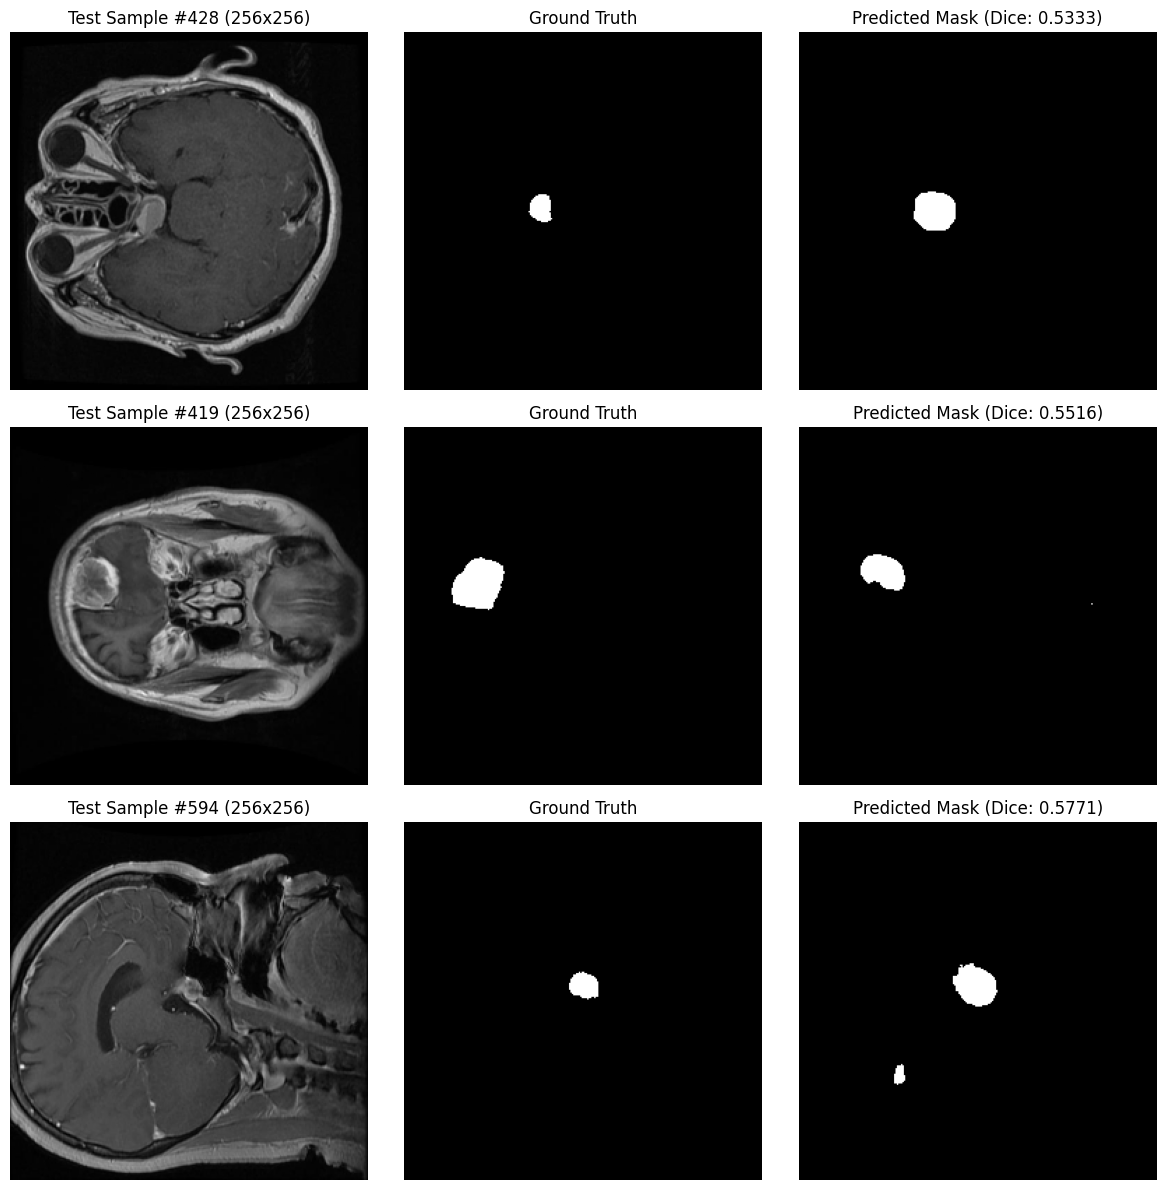

In [34]:
# Cell 8: Visualize 3 Random Predictions from Test Set

import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. Path to model checkpoint
MODEL_PATH = "saved_models/best_unet_256.pth"

# 2. Load model weights
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
    print(f"Loaded model weights from: {MODEL_PATH}")
else:
    print(f"Warning: File {MODEL_PATH} not found. Using current model in memory.")

model.eval()

# 3. Select 3 random indices from the test set
test_size = len(test_dataset)
random_indices = random.sample(range(test_size), 3)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# 4. Process and plot each random sample
for row, idx in enumerate(random_indices):
    img_tensor, mask_tensor = test_dataset[idx]
    
    # Add batch dimension and move to GPU
    img_input = img_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        raw_pred = model(img_input)
        
        # Apply sigmoid if raw logits
        if raw_pred.min() < 0 or raw_pred.max() > 1:
            prob = torch.sigmoid(raw_pred)
        else:
            prob = raw_pred
            
        pred_mask = (prob.squeeze().cpu().numpy() > 0.5).astype(np.float32)

    # Convert tensors for plotting
    img = img_tensor.permute(1, 2, 0).numpy()
    gt = mask_tensor.squeeze().numpy()
    
    # Compute per-sample Dice score
    intersection = np.sum(pred_mask * gt)
    dice_score = (2. * intersection + 1e-6) / (np.sum(pred_mask) + np.sum(gt) + 1e-6)
    
    h, w = img.shape[:2]

    # Input Image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Test Sample #{idx} ({w}x{h})")
    axes[row, 0].axis("off")

    # Ground Truth Mask
    axes[row, 1].imshow(gt, cmap="gray")
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    # Model Prediction
    axes[row, 2].imshow(pred_mask, cmap="gray")
    axes[row, 2].set_title(f"Predicted Mask (Dice: {dice_score:.4f})")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

Loaded weights from: saved_models/best_unet_256.pth


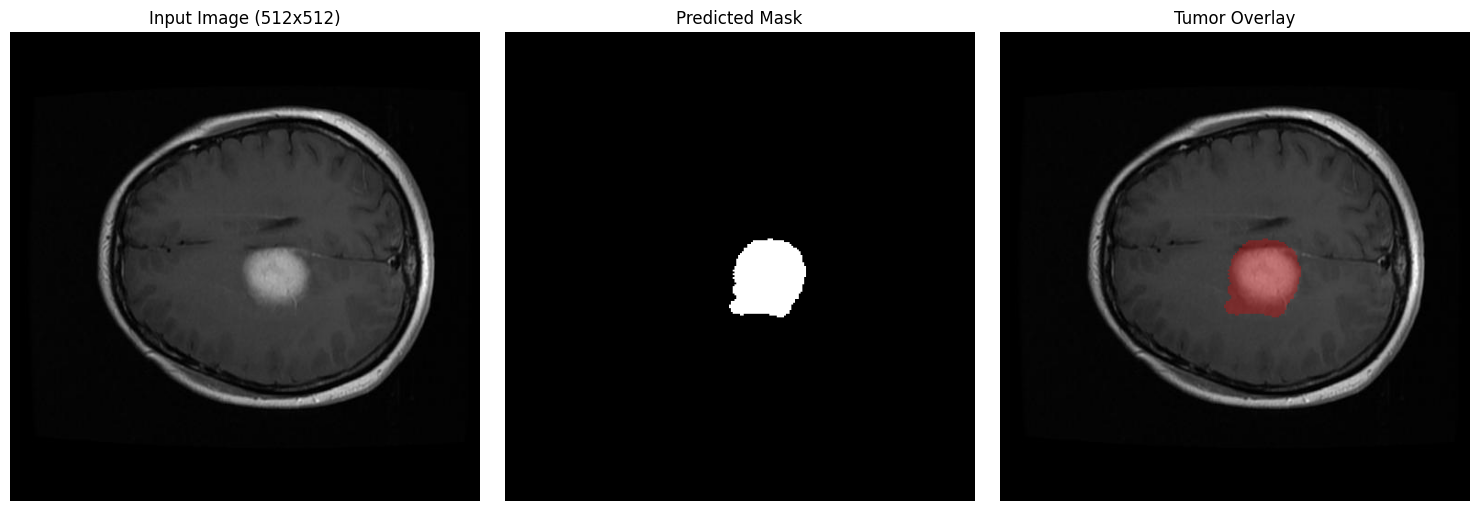

Saved prediction to: output_predictions\pred_nova_slika.jpg



In [36]:
import os
import cv2
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIGURATION ----------------
MODEL_PATH = "saved_models/best_unet_256.pth"
INPUT_PATH = "nova_slika.jpg"  # File path (.png/.jpg) OR directory path
OUTPUT_DIR = "output_predictions"
IMG_SIZE = (256, 256)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------- 1. LOAD MODEL ----------------
model = UNet(in_channels=3, out_channels=1).to(DEVICE)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
    print(f"Loaded weights from: {MODEL_PATH}")
else:
    raise FileNotFoundError(f"Model checkpoint not found at {MODEL_PATH}")

model.eval()

# ---------------- 2. PREPROCESS & INFER ----------------
def predict_single_image(image_path):
    # Read original image
    raw_img = cv2.imread(image_path)
    if raw_img is None:
        print(f"Skipping unreadable file: {image_path}")
        return
        
    orig_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = orig_rgb.shape[:2]

    # Preprocess (Resize to 256x256 & Normalize to [0, 1])
    img_resized = cv2.resize(orig_rgb, IMG_SIZE) / 255.0
    img_tensor = torch.tensor(img_resized, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    # Model Inference
    with torch.no_grad():
        raw_pred = model(img_tensor)
        prob = torch.sigmoid(raw_pred) if (raw_pred.min() < 0 or raw_pred.max() > 1) else raw_pred
        pred_mask = (prob.squeeze().cpu().numpy() > 0.5).astype(np.float32)

    # Resize mask back to original image dimensions
    pred_mask_orig = cv2.resize(pred_mask, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)

    # Create Red Overlay on Original Image
    overlay = orig_rgb.copy()
    overlay[pred_mask_orig == 1.0] = [255, 0, 0]  # Red tumor highlight
    blended = cv2.addWeighted(orig_rgb, 0.7, overlay, 0.3, 0)

    # ---------------- 3. PLOT, DISPLAY & SAVE RESULT ----------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(orig_rgb)
    axes[0].set_title(f"Input Image ({w_orig}x{h_orig})")
    axes[0].axis("off")

    axes[1].imshow(pred_mask_orig, cmap="gray")
    axes[1].set_title("Predicted Mask")
    axes[1].axis("off")

    axes[2].imshow(blended)
    axes[2].set_title("Tumor Overlay")
    axes[2].axis("off")

    filename = os.path.basename(image_path)
    save_path = os.path.join(OUTPUT_DIR, f"pred_{filename}")
    plt.tight_layout()
    
    # Save figure to disk
    plt.savefig(save_path, bbox_inches="tight")
    
    # Render directly in Jupyter cell output
    plt.show()

    print(f"Saved prediction to: {save_path}\n")

# ---------------- 4. EXECUTE INFERENCE ----------------
if os.path.isfile(INPUT_PATH):
    predict_single_image(INPUT_PATH)
elif os.path.isdir(INPUT_PATH):
    image_extensions = ("*.png", "*.jpg", "*.jpeg", "*.tif")
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(INPUT_PATH, ext)))
    
    print(f"Found {len(image_files)} images in folder.\n")
    for img_path in image_files:
        predict_single_image(img_path)
else:
    print(f"Invalid path: {INPUT_PATH}")